# Clustering (Unsupervised Machine Learning)
Clustering is the task of dividing the population or data points into a number of groups such that data points in the same groups are more similar to other data points in the same group than those in other groups. In simple words, the aim is to segregate groups with similar traits and assign them into clusters.

Let’s understand this with an example. Suppose, you are the head of a rental store and wish to understand preferences of your costumers to scale up your business. Is it possible for you to look at details of each costumer and devise a unique business strategy for each one of them? Definitely not. But, what you can do is to cluster all of your costumers into say 10 groups based on their purchasing habits and use a separate strategy for costumers in each of these 10 groups. And this is what we call clustering.

In [1]:
# Suppresing the warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Importing the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Reading the dataset

MallData = pd.read_csv("C:\\Users\\Abhishek Roy\\OneDrive\\Desktop\\ML Practise\\Datasets\\Mall_Customers.csv")

print("Shape of the dataset before dropping duplicates :", MallData.shape)

# Dropping duplicate records from the dataset
MallData = MallData.drop_duplicates()

print("Shape of the dataset after dropping duplicates :", MallData.shape)


Shape of the dataset before dropping duplicates : (200, 5)
Shape of the dataset after dropping duplicates : (200, 5)


# Basic Data Exploration

In [4]:
MallData.head(5)

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [5]:
# Dropping the useless columns from the data :

UselessCols = ['CustomerID']
MallData.drop(UselessCols,axis=1,inplace=True)
MallData.head(5)

,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


# Mall Customer Segmentation using Clustering

In [6]:
# Seperating the target variable

TargetVariable = MallData['Spending Score (1-100)']

# Seperating the predictors

OnlyPredictors = MallData[['Genre','Age','Annual Income (k$)']]
OnlyPredictors.head(5)

,Genre,Age,Annual Income (k$)
0,Male,19,15
1,Male,21,15
2,Female,20,16
3,Female,23,16
4,Female,31,17


In [7]:
# Converting Binary variables

MallData.replace({'Male':1,'Female':0},inplace=True)

In [8]:
OnlyPredictors.head(3)

,Genre,Age,Annual Income (k$)
0,Male,19,15
1,Male,21,15
2,Female,20,16


In [9]:
# Taking out only the predictor variables

#X = OnlyPredictors.values
#y = TargetVariable.values

X=MallData.values

In [10]:
# Printing some sample values

X[0:5]

array([[ 1, 19, 15, 39],
       [ 1, 21, 15, 81],
       [ 0, 20, 16,  6],
       [ 0, 23, 16, 77],
       [ 0, 31, 17, 40]], dtype=int64)

### Finding the best number of clusters based on the inertia value

In [11]:
# Finding the best number of clusters based on the inertia value

from sklearn.cluster import KMeans
interiaValue = []

for i in range(1, 13):
    
    KM = KMeans(n_clusters=i, 
                init='random',
                n_init=10, 
                max_iter=300,
                tol=1e-04,
                random_state=0).fit(X)
    
    # Appending the inertia value at each step 
    interiaValue.append(KM.inertia_)

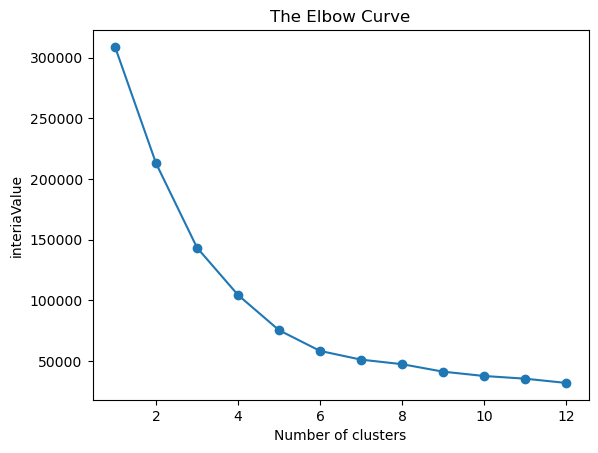

The inertia values are :  [308862.06, 212889.442455243, 143391.59236035674, 104414.67534220166, 75399.61541401484, 58348.64136331505, 51165.184237107926, 47416.60704781153, 41256.41596736596, 37689.49407787334, 35471.64810032149, 31968.47686115055]


In [12]:
# plotting the graph

plt.plot(range(1,13),interiaValue, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('interiaValue')
plt.title('The Elbow Curve')
plt.show()
print("The inertia values are : ", interiaValue)

In [13]:
# Using above graph deciding optimal number of clusters, here n = 5

# fitting the k means to the dataset using the number of cluster obtained from the above graph
KM = KMeans(n_clusters=5, 
                init='random',
                n_init=10, 
                max_iter=300,
                tol=1e-04,
                random_state=0).fit(X)

# Predicting the clusters for each record of the dataset
PredictedClusters = KM.fit_predict(X)
print(PredictedClusters)
print(KM.inertia_)

[1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1
 0 1 0 1 0 1 0 1 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 3 4 3 2 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 2 3 4 3 4 3
 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4
 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3]
75399.61541401484


In [14]:
# Appending the cluster number to the dataset
MallData['PredictedCluster'] = PredictedClusters
MallData.head(10)

,Genre,Age,Annual Income (k$),Spending Score (1-100),PredictedCluster
0,1,19,15,39,1
1,1,21,15,81,0
2,0,20,16,6,1
3,0,23,16,77,0
4,0,31,17,40,1
5,0,22,17,76,0
6,0,35,18,6,1
7,0,23,18,94,0
8,1,64,19,3,1
9,0,30,19,72,0


<Axes: xlabel='PredictedCluster'>

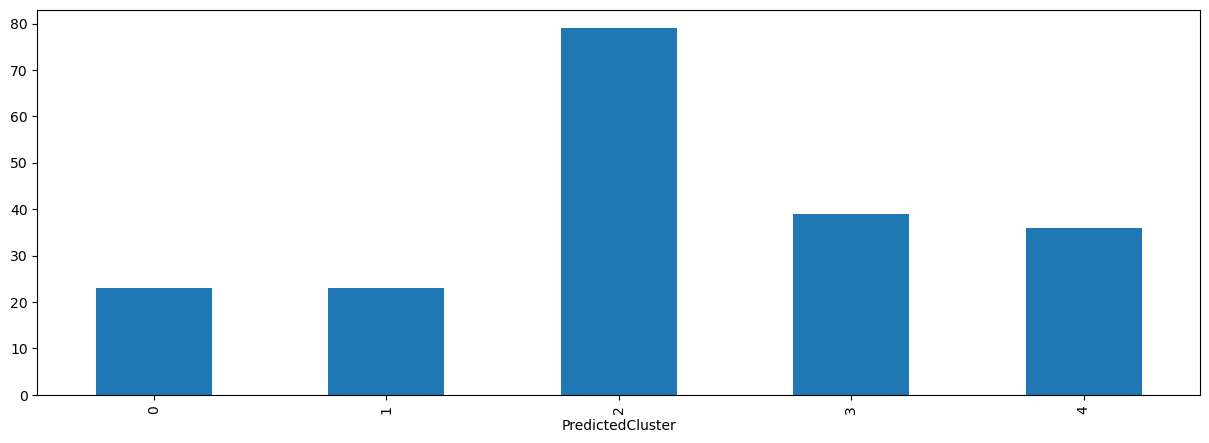

In [15]:
# the number of points in each cluster
MallData.groupby('PredictedCluster').size().plot(kind='bar',figsize=(15,5))

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


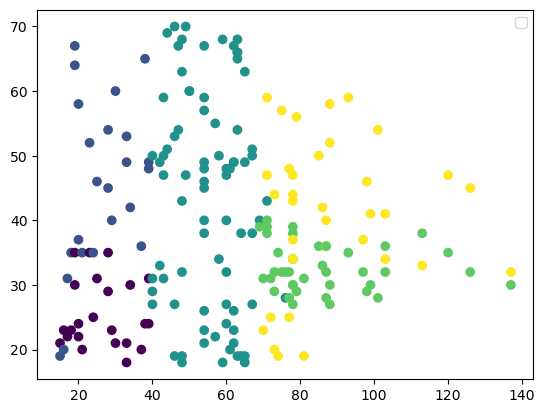

In [16]:
# create scatter plot to visualize the data
# Choose those two continuous columns which has maximum range of values
%matplotlib inline
plt.scatter(x=MallData['Annual Income (k$)'], y=MallData['Age'], c=MallData['PredictedCluster'])
plt.legend()

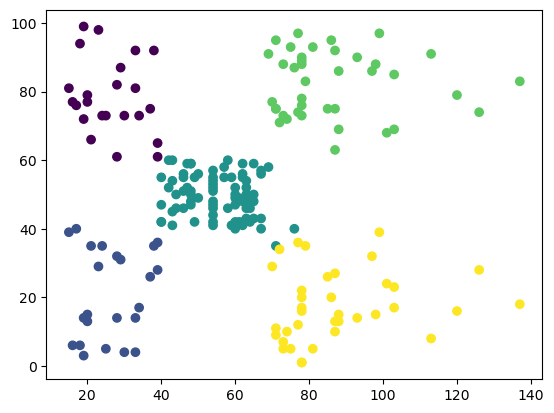

In [17]:
%matplotlib inline
plt.scatter(x=MallData['Annual Income (k$)'],y=MallData['Spending Score (1-100)'],c=MallData['PredictedCluster'])
plt.show()